In [1]:
import yt
import numpy as np
from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

/tmp/ipykernel_3883063/1641255397.py:3: VisibleDeprecationWarning: The yt.mods module is deprecated.
Deprecated since yt 4.1.0
This feature is planned for removal in yt 4.2.0
  from yt.mods import *


In [3]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [4]:
path = "../Output_12_shortrun/plt0????"
dsLoad = AMReXDatasetSeries(path)

In [5]:
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2024-12-08 18:24:48,037 Parameters: current_time              = 0.0
yt : [INFO     ] 2024-12-08 18:24:48,038 Parameters: domain_dimensions         = [12 12 12]
yt : [INFO     ] 2024-12-08 18:24:48,038 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-08 18:24:48,039 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2024-12-08 18:24:48,111 Parameters: current_time              = 0.603711863956227
yt : [INFO     ] 2024-12-08 18:24:48,112 Parameters: domain_dimensions         = [12 12 12]
yt : [INFO     ] 2024-12-08 18:24:48,113 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2024-12-08 18:24:48,113 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2024-12-08 18:24:48,173 Parameters: current_time              = 1.20742372791245
yt : [INFO     ] 2024-12-08 18:24:48,174 Parameters: domain_dimensions         = [12 12 12]
yt : [INFO     ] 2024-12-08 18:24:48,175 Parameters: domain_left_edge     

In [6]:
def _relRef (field, data):
    av = data.ds.all_data().quantities.weighted_average_quantity("SCHf_Re", weight = ("index", "ones"))
    return data["SCHf_Re"]/av
for data in ds:
    data.add_field(("boxlib","SCHf_Re"), function=_relRef, sampling_type="local", units="dimensionless")

yt : [WARNING  ] 2024-12-08 18:24:54,786 Field ('boxlib', 'SCHf_Re') already exists. To override use `force_override=True`.


yt : [INFO     ] 2024-12-08 18:25:07,974 xlim = 0.000000 1.000000
yt : [INFO     ] 2024-12-08 18:25:07,975 ylim = 0.000000 1.000000
yt : [INFO     ] 2024-12-08 18:25:07,976 xlim = 0.000000 1.000000
yt : [INFO     ] 2024-12-08 18:25:07,976 ylim = 0.000000 1.000000
yt : [INFO     ] 2024-12-08 18:25:07,983 Making a fixed resolution buffer of (('boxlib', 'SCHf_Re')) 800 by 800



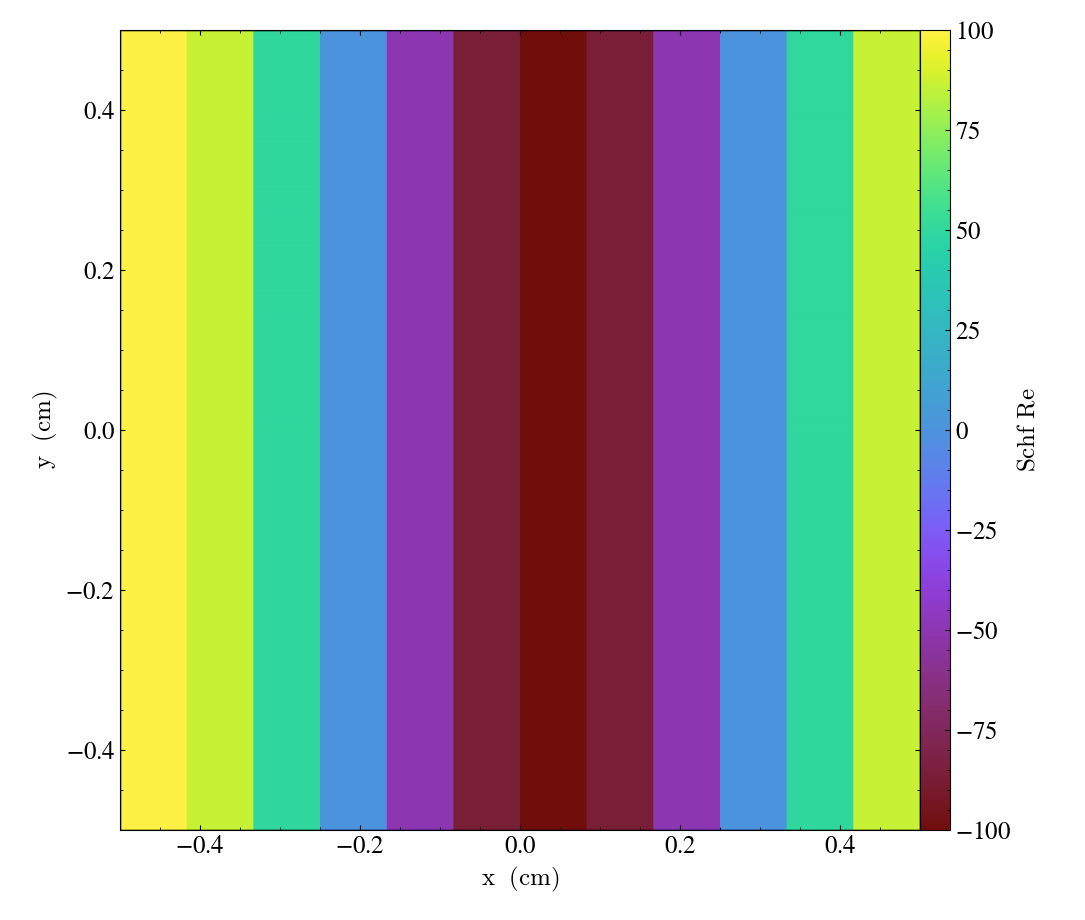

In [7]:
plot = yt.SlicePlot(ds[0], "z", "SCHf_Re")#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log("SCHf_Re", False)
#plot.show()
plot.annotate_grids()

In [8]:
fig = plot.plots[("boxlib", "SCHf_Re")].figure

In [9]:
def animate(i):
    ts = ds[i]
    plot._switch_ds(ts)

In [10]:
animation = FuncAnimation(fig, animate, frames=len(ds))

In [11]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)